# Cross-layer EDA 04: Gene-pair relationships

This notebook brings three biologically different gene-pair routes into one **explainable evidence view** without blending them into a hidden score.

1. **Direct fusion:** is there a measured RNA fusion call physically joining the two genes?
2. **CRISPR codependency:** do cell lines tend to depend on both genes in a similar pattern?
3. **Conditional dependency:** when Gene A is altered, lost, gained, or highly expressed, does the cell become more dependent on Gene B?

These routes answer different questions. Agreement is useful, but one route does not replace another. The final dashboard should show the route, the metric, the denominator, and the caveat instead of presenting an unexplained percentage.

## Guardrails

- `model_id` is the only automatic model-level join key.
- Fusion and codependency are represented as undirected pairs; conditional dependency is directional.
- Mutation, copy-number loss, copy-number gain, and RNA-high contexts remain separate.
- Assay absence is missing evidence, never a biological zero.
- Every statistic carries its actual model denominator.
- Lineage-adjusted results exclude lineages with fewer than 15 measured models; conditional comparisons also require at least 10 models in both groups.
- Common-essential genes remain visible as a warning about broad dependency.
- Positive signals are exploratory evidence, not proof of a viable pair or a calibrated probability.

In [1]:
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from matplotlib.lines import Line2D
from scipy.stats import rankdata

pd.set_option('display.max_columns', 140)
pd.set_option('display.max_rows', 140)
sns.set_theme(style='whitegrid', context='notebook')


def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / 'data' / 'depmap_24Q4' / 'architecture' / 'model_master.csv').exists():
            return candidate
    raise FileNotFoundError('Run this notebook from inside the az-team25 repository.')


def canonical_pair(gene_a: str, gene_b: str) -> str:
    return '--'.join(sorted([str(gene_a).upper(), str(gene_b).upper()]))


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
DATA = PROJECT_ROOT / 'data' / 'depmap_24Q4'
PATHS = {
    'master': DATA / 'architecture' / 'model_master.csv',
    'gene_master': DATA / 'architecture' / 'gene_master.csv',
    'crispr_context': DATA / 'architecture' / 'model_crispr_context.csv',
    'fusion_pairs': DATA / 'architecture' / 'fusion_pair_evidence.csv',
    'effect': DATA / 'raw' / 'CRISPRGeneEffect.csv',
    'dependency': DATA / 'raw' / 'CRISPRGeneDependency.csv',
    'mutations': DATA / 'derived' / 'mutations_default_dna_gene_summary.csv',
    'copy_number': DATA / 'raw' / 'OmicsAbsoluteCNGene.csv',
    'expression': DATA / 'derived' / 'expression_default_rna_model.csv',
}

master = pd.read_csv(PATHS['master'], low_memory=False)
gene_master = pd.read_csv(PATHS['gene_master'], low_memory=False)
crispr_context = pd.read_csv(PATHS['crispr_context'], low_memory=False)
fusion_calls = pd.read_csv(PATHS['fusion_pairs'], low_memory=False)
mutations = pd.read_csv(PATHS['mutations'], low_memory=False)

assert master['model_id'].is_unique
assert gene_master['symbol'].is_unique
assert crispr_context['model_id'].is_unique
assert not fusion_calls.duplicated(['model_id', 'fusion_pair_id']).any()

master['oncotree_lineage'] = master['oncotree_lineage'].fillna('Unknown')
lineage_lookup = master.set_index('model_id')['oncotree_lineage']

print(f'Identity spine: {len(master):,} models')
print(f'CRISPR gene-effect models: {master.has_crispr_gene_effect.sum():,}')
print(f'Fusion-assayed models: {master.has_fusion_assay.sum():,}')
print(f'Models with a retained filtered fusion call: {master.has_any_filtered_fusion_call.sum():,}')
print(f'Observed canonical fusion pairs: {fusion_calls.fusion_pair_id.nunique():,}')

Identity spine: 2,105 models
CRISPR gene-effect models: 1,178
Fusion-assayed models: 1,672
Models with a retained filtered fusion call: 1,670
Observed canonical fusion pairs: 27,256


## Column dictionary

| Column | Meaning | Project use |
|---|---|---|
| `pair_id` | Alphabetically ordered gene symbols, such as `ALK--EML4`. | Stable undirected key for fusion and codependency evidence. |
| `directional_pair_id` | Ordered hypothesis such as `ARID1A -> EZH2`. | Preserves which gene defines the context and which gene is knocked out. |
| `route_family` | `direct_fusion`, `crispr_codependency`, or `conditional_dependency`. | Lets the dashboard explain which biological route supplied evidence. |
| `route_state` | Whether the route was not measurable, insufficient, measured without material positive signal, or positive. | Separates missing evidence from negative or weak evidence. Codependency uses a visible exploratory `rho >= 0.10` threshold. |
| `metric_name` | Name of the route-specific strength measure. | Prevents unlike measurements from being silently combined. |
| `metric_value` | Numeric value of the named route metric. | Strength shown beside its route, not as a universal score. |
| `models_with_direct_fusion` | Models with a retained filtered call for the exact gene pair. | Direct physical-connection numerator. |
| `fusion_assayed_models` | Models eligible for the fusion route. | Direct fusion denominator; absence of a call is interpreted only within this assay cohort. |
| `total_junction_reads` | Reads crossing the fusion junction, summed over models. | Technical support for the observed fusion transcript. |
| `total_spanning_fragments` | Fragments supporting both sides of the fusion. | Second form of technical support. |
| `max_ffpm` | Largest fusion fragments-per-million value observed for the pair. | Relative abundance of the strongest call, not biological validity by itself. |
| `models_with_large_anchor_support` | Called models passing the source's large-anchor support flag. | Additional fusion-call quality context. |
| `codependency_models` | Models with gene-effect values for both genes. | Raw codependency denominator. |
| `raw_gene_effect_rho` | Spearman correlation between the two CRISPR gene-effect profiles. | Positive values mean dependency patterns move together. |
| `lineage_adjusted_codependency_rho` | Correlation after subtracting each lineage's median dependency. | Reduces broad tissue-of-origin confounding. |
| `dependency_probability_rho` | Correlation on the supporting dependency-probability matrix. | Checks whether the pattern is also visible on the probability scale. |
| `gene_a_common_essential`, `gene_b_common_essential` | Whether either gene is broadly essential across many cell lines. | Warns that codependency may reflect general cell fitness rather than selective biology. |
| `context_type` | Mutation, copy-number loss, copy-number gain, or RNA-high state. | Keeps conditional hypotheses biologically distinct. |
| `context_definition` | Exact threshold or rule defining Gene A's state. | Makes feature engineering auditable. |
| `context_models`, `reference_models` | Measured models in the altered and comparison groups. | Exact conditional-dependency denominators. |
| `dependency_shift` | Reference median gene effect minus context median gene effect. | Positive means Gene A's context is associated with stronger dependency on Gene B. |
| `lineage_adjusted_dependency_shift` | The same shift after subtracting lineage medians. | Primary conditional strength measure used here. |
| `dependency_probability_shift` | Context minus reference median dependency probability. | Supporting conditional evidence. |
| `is_common_essential_target` | Whether conditional target Gene B is broadly essential. | Warns against mistaking a universal dependency for a selective pair. |
| `routes_with_positive_signal` | Text list of routes with an observed positive exploratory signal. | Dashboard navigation only; it is not a score or probability. |

## 1. Pair vocabulary and assay coverage

The pair panel below contains recognisable fusion examples, conditional-dependency hypotheses, and comparison pairs for codependency. It is an EDA panel, not an answer key. The same functions can later be applied to a user-supplied pair.

,input_gene_a,input_gene_b,example_reason,pair_id,gene_a,gene_b
0,BCR,ABL1,Direct fusion example,ABL1--BCR,ABL1,BCR
1,EML4,ALK,Direct fusion example,ALK--EML4,ALK,EML4
2,TMPRSS2,ERG,Direct fusion example,ERG--TMPRSS2,ERG,TMPRSS2
3,EWSR1,FLI1,Direct fusion example,EWSR1--FLI1,EWSR1,FLI1
4,ARID1A,EZH2,Chromatin conditional-dependency hypothesis,ARID1A--EZH2,ARID1A,EZH2
5,SMARCA4,SMARCA2,Paralog conditional-dependency hypothesis,SMARCA2--SMARCA4,SMARCA2,SMARCA4
6,BRCA1,PARP1,DNA-repair conditional-dependency hypothesis,BRCA1--PARP1,BRCA1,PARP1
7,BRCA2,PARP1,DNA-repair conditional-dependency hypothesis,BRCA2--PARP1,BRCA2,PARP1
8,KRAS,RAF1,Signalling conditional-dependency hypothesis,KRAS--RAF1,KRAS,RAF1
9,MTAP,PRMT5,Copy-loss conditional-dependency hypothesis,MTAP--PRMT5,MTAP,PRMT5


,gene,expression_column,crispr_effect_column,crispr_dependency_column,copy_number_column,is_crispr_common_essential,has_expression,has_crispr_effect,has_crispr_dependency,has_copy_number
0,ABL1,ABL1 (ENSG00000097007),ABL1 (25),ABL1 (25),ABL1 (25),0,True,True,True,True
1,ALK,ALK (ENSG00000171094),ALK (238),ALK (238),ALK (238),0,True,True,True,True
2,ARID1A,ARID1A (ENSG00000117713),ARID1A (8289),ARID1A (8289),ARID1A (8289),0,True,True,True,True
3,BCR,BCR (ENSG00000186716),BCR (613),BCR (613),BCR (613),0,True,True,True,True
4,BRAF,BRAF (ENSG00000157764),BRAF (673),BRAF (673),BRAF (673),0,True,True,True,True
5,BRCA1,BRCA1 (ENSG00000012048),BRCA1 (672),BRCA1 (672),BRCA1 (672),0,True,True,True,True
6,BRCA2,BRCA2 (ENSG00000139618),BRCA2 (675),BRCA2 (675),BRCA2 (675),0,True,True,True,True
7,CDK4,CDK4 (ENSG00000135446),CDK4 (1019),CDK4 (1019),CDK4 (1019),1,True,True,True,True
8,EML4,EML4 (ENSG00000143924),EML4 (27436),EML4 (27436),EML4 (27436),0,True,True,True,True
9,ERG,ERG (ENSG00000157554),ERG (2078),ERG (2078),ERG (2078),0,True,True,True,True


,route,models,eligibility_rule
0,Direct fusion,1672,has_fusion_assay = 1
1,CRISPR codependency,1178,released gene effect + dependency
2,Mutation -> CRISPR,1178,mutation assay + gene effect
3,Copy number -> CRISPR,948,absolute CN + gene effect
4,RNA -> CRISPR,1103,default RNA + gene effect


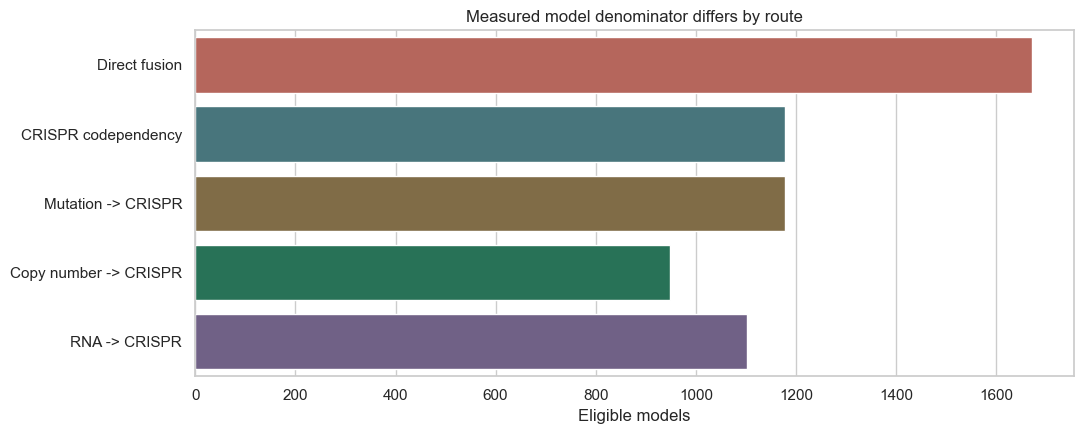

In [2]:
pair_specs = [
    ('BCR', 'ABL1', 'Direct fusion example'),
    ('EML4', 'ALK', 'Direct fusion example'),
    ('TMPRSS2', 'ERG', 'Direct fusion example'),
    ('EWSR1', 'FLI1', 'Direct fusion example'),
    ('ARID1A', 'EZH2', 'Chromatin conditional-dependency hypothesis'),
    ('SMARCA4', 'SMARCA2', 'Paralog conditional-dependency hypothesis'),
    ('BRCA1', 'PARP1', 'DNA-repair conditional-dependency hypothesis'),
    ('BRCA2', 'PARP1', 'DNA-repair conditional-dependency hypothesis'),
    ('KRAS', 'RAF1', 'Signalling conditional-dependency hypothesis'),
    ('MTAP', 'PRMT5', 'Copy-loss conditional-dependency hypothesis'),
    ('MTAP', 'MAT2A', 'Copy-loss conditional-dependency hypothesis'),
    ('BRCA1', 'BRCA2', 'CRISPR codependency comparison'),
    ('CDK4', 'MDM2', 'CRISPR codependency comparison'),
    ('BRAF', 'MAPK1', 'CRISPR codependency comparison'),
    ('STK11', 'KEAP1', 'CRISPR codependency comparison'),
]
pair_catalog = pd.DataFrame(pair_specs, columns=['input_gene_a', 'input_gene_b', 'example_reason'])
pair_catalog['pair_id'] = [canonical_pair(a, b) for a, b in pair_catalog[['input_gene_a', 'input_gene_b']].itertuples(index=False, name=None)]
pair_catalog[['gene_a', 'gene_b']] = pair_catalog['pair_id'].str.split('--', expand=True)
assert pair_catalog['pair_id'].is_unique

panel_genes = sorted(set(pair_catalog['gene_a']) | set(pair_catalog['gene_b']))
gene_lookup = gene_master.set_index('symbol')
gene_availability = gene_lookup.reindex(panel_genes)[[
    'expression_column', 'crispr_effect_column', 'crispr_dependency_column',
    'copy_number_column', 'is_crispr_common_essential'
]].reset_index(names='gene')
gene_availability['has_expression'] = gene_availability['expression_column'].notna()
gene_availability['has_crispr_effect'] = gene_availability['crispr_effect_column'].notna()
gene_availability['has_crispr_dependency'] = gene_availability['crispr_dependency_column'].notna()
gene_availability['has_copy_number'] = gene_availability['copy_number_column'].notna()

route_coverage = pd.DataFrame([
    {'route': 'Direct fusion', 'models': int(master['has_fusion_assay'].sum()), 'eligibility_rule': 'has_fusion_assay = 1'},
    {'route': 'CRISPR codependency', 'models': int(master['eligible_codependency_route'].sum()), 'eligibility_rule': 'released gene effect + dependency'},
    {'route': 'Mutation -> CRISPR', 'models': int((master['has_mutation_assay'].eq(1) & master['has_crispr_gene_effect'].eq(1)).sum()), 'eligibility_rule': 'mutation assay + gene effect'},
    {'route': 'Copy number -> CRISPR', 'models': int((master['has_absolute_copy_number'].eq(1) & master['has_crispr_gene_effect'].eq(1)).sum()), 'eligibility_rule': 'absolute CN + gene effect'},
    {'route': 'RNA -> CRISPR', 'models': int((master['has_expression'].eq(1) & master['has_crispr_gene_effect'].eq(1)).sum()), 'eligibility_rule': 'default RNA + gene effect'},
])

display(pair_catalog)
display(gene_availability)
display(route_coverage)

plt.figure(figsize=(11, 4.5))
sns.barplot(data=route_coverage, x='models', y='route', hue='route', legend=False,
            palette=['#c45b4d', '#3f7c85', '#8a6f3d', '#1b7f5a', '#6f5b8c'])
plt.title('Measured model denominator differs by route')
plt.xlabel('Eligible models'); plt.ylabel('')
plt.tight_layout(); plt.show()

### What this means for the project

A gene pair does not have one universal denominator. Fusion evidence comes from fusion-assayed models, while codependency requires both CRISPR profiles, and conditional dependency needs both a molecular assay and CRISPR. For example, “no fusion observed” means no retained call among fusion-assayed models; it does not mean the genes can never fuse. This is why the dashboard must show route-specific coverage beside every result.

## 2. Direct fusion route

A fusion is the most literal connection in this notebook: parts of two genes are found in one RNA transcript. We summarise exact pair recurrence and read support. The 24Q4 files used here do not provide reading-frame or retained-protein-domain evidence, so this route can show a measured fusion call but cannot prove that the transcript makes a functional protein.

,pair_id,gene_a,gene_b,gene_a_symbol,gene_b_symbol,models_with_direct_fusion,lineages_with_direct_fusion,total_junction_reads,total_spanning_fragments,max_ffpm,models_with_large_anchor_support,observed_lineages,fusion_assayed_models,direct_fusion_model_fraction_pct,route_state
0,ABL1--BCR,ABL1,BCR,ABL1,BCR,24,2,3768,3134,7.9447,24,Lymphoid | Myeloid,1672,1.435407,direct_pair_observed
3,EWSR1--FLI1,EWSR1,FLI1,EWSR1,FLI1,20,2,3415,2752,7.1792,20,Bone | CNS/Brain,1672,1.196172,direct_pair_observed
1,ALK--EML4,ALK,EML4,ALK,EML4,7,4,331,615,2.0730,7,Bowel | Lung | Pancreas | Peripheral Nervous S...,1672,0.418660,direct_pair_observed
2,ERG--TMPRSS2,ERG,TMPRSS2,ERG,TMPRSS2,2,1,413,133,2.5995,2,Prostate,1672,0.119617,direct_pair_observed
4,ARID1A--EZH2,ARID1A,EZH2,NaN,NaN,0,0,0,0,0.0000,0,,1672,0.000000,assayed_no_retained_pair_call
5,SMARCA2--SMARCA4,SMARCA2,SMARCA4,NaN,NaN,0,0,0,0,0.0000,0,,1672,0.000000,assayed_no_retained_pair_call
6,BRCA1--PARP1,BRCA1,PARP1,NaN,NaN,0,0,0,0,0.0000,0,,1672,0.000000,assayed_no_retained_pair_call
7,BRCA2--PARP1,BRCA2,PARP1,NaN,NaN,0,0,0,0,0.0000,0,,1672,0.000000,assayed_no_retained_pair_call
8,KRAS--RAF1,KRAS,RAF1,NaN,NaN,0,0,0,0,0.0000,0,,1672,0.000000,assayed_no_retained_pair_call
9,MTAP--PRMT5,MTAP,PRMT5,NaN,NaN,0,0,0,0,0.0000,0,,1672,0.000000,assayed_no_retained_pair_call


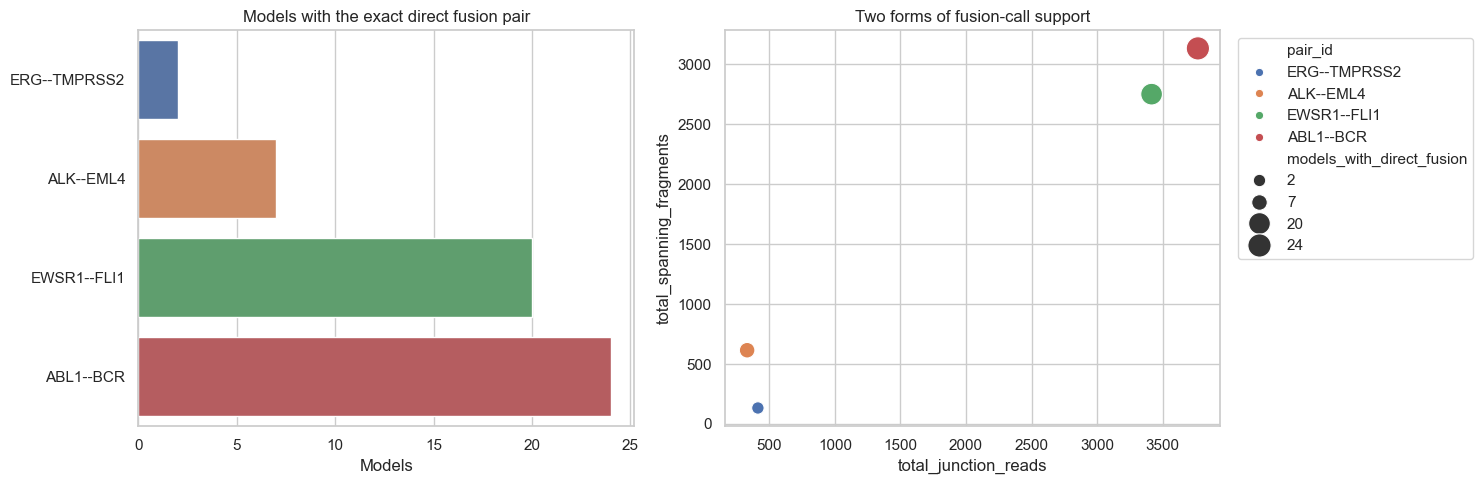

,pair_id,models_with_direct_fusion,lineages_with_direct_fusion,total_junction_reads,total_spanning_fragments,max_ffpm
25797,RPL37--RPL37P15,325,23,11716,0,1.6414
9299,CAPNS1--FP236383.2,209,22,954,2046,0.5969
16312,GAPDH--MT-ND4L,197,21,1073,1749,0.3206
3322,AC126544.2--KANSL1,184,26,1356,3369,1.3843
16311,GAPDH--MT-ND4,135,18,585,1591,0.4734
27147,UBA52--UBB,132,21,592,1480,0.4394
6427,AP000534.2--DUXAP10,120,23,1288,348,1.6687
6836,APP--MT-CO3,115,23,585,634,0.3786
23014,NCL--PTMA,114,17,661,2577,0.5822
22059,MT-CO3--YBX1,108,21,501,299,0.2001


In [3]:
fusion_assayed_models = int(master['has_fusion_assay'].sum())
fusion_model_context = fusion_calls.merge(
    master[['model_id', 'oncotree_lineage', 'cell_line_name']],
    on='model_id', how='left', validate='many_to_one'
)

fusion_summary_all = (
    fusion_model_context.groupby(['fusion_pair_id', 'gene_a_symbol', 'gene_b_symbol'], as_index=False)
    .agg(
        models_with_direct_fusion=('model_id', 'nunique'),
        lineages_with_direct_fusion=('oncotree_lineage', 'nunique'),
        total_junction_reads=('total_junction_reads', 'sum'),
        total_spanning_fragments=('total_spanning_fragments', 'sum'),
        max_ffpm=('max_ffpm', 'max'),
        models_with_large_anchor_support=('has_large_anchor_support', 'sum'),
        observed_lineages=('oncotree_lineage', lambda s: ' | '.join(sorted(set(s.dropna().astype(str)))))
    )
    .rename(columns={'fusion_pair_id': 'pair_id'})
)

fusion_route = pair_catalog[['pair_id', 'gene_a', 'gene_b']].merge(
    fusion_summary_all, on='pair_id', how='left', validate='one_to_one'
)
count_columns = [
    'models_with_direct_fusion', 'lineages_with_direct_fusion', 'total_junction_reads',
    'total_spanning_fragments', 'models_with_large_anchor_support'
]
fusion_route[count_columns] = fusion_route[count_columns].fillna(0).astype(int)
fusion_route['max_ffpm'] = fusion_route['max_ffpm'].fillna(0.0)
fusion_route['observed_lineages'] = fusion_route['observed_lineages'].fillna('')
fusion_route['fusion_assayed_models'] = fusion_assayed_models
fusion_route['direct_fusion_model_fraction_pct'] = 100 * fusion_route['models_with_direct_fusion'] / fusion_assayed_models
fusion_route['route_state'] = np.where(
    fusion_route['models_with_direct_fusion'].gt(0),
    'direct_pair_observed', 'assayed_no_retained_pair_call'
)

display(fusion_route.sort_values(['models_with_direct_fusion', 'total_junction_reads'], ascending=False))

observed_fusion = fusion_route.loc[fusion_route['models_with_direct_fusion'].gt(0)].sort_values('models_with_direct_fusion')
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(data=observed_fusion, x='models_with_direct_fusion', y='pair_id', hue='pair_id', legend=False, ax=axes[0])
axes[0].set_title('Models with the exact direct fusion pair'); axes[0].set_xlabel('Models'); axes[0].set_ylabel('')
sns.scatterplot(data=observed_fusion, x='total_junction_reads', y='total_spanning_fragments',
                size='models_with_direct_fusion', hue='pair_id', sizes=(80, 280), ax=axes[1])
axes[1].set_title('Two forms of fusion-call support')
axes[1].legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout(); plt.show()

top_recurrent = fusion_summary_all.nlargest(20, ['models_with_direct_fusion', 'total_junction_reads'])
display(top_recurrent[[
    'pair_id', 'models_with_direct_fusion', 'lineages_with_direct_fusion',
    'total_junction_reads', 'total_spanning_fragments', 'max_ffpm'
]])

### What this means for the project

`ABL1--BCR`, `EWSR1--FLI1`, `ALK--EML4`, and `ERG--TMPRSS2` demonstrate what direct evidence looks like: the exact pair appears in specific cell lines and is supported by junction reads and spanning fragments. Some of the most recurrent raw pairs involve highly expressed housekeeping genes. Therefore, recurrence and read support are useful technical features, but neither should be translated directly into “biological confidence.” Later enrichment from curated fusion knowledge can label known driver fusions while keeping the observed DepMap measurements unchanged.

## 3. CRISPR codependency route

CRISPR codependency compares two genes across cell lines. If knocking out Gene A and Gene B produces similar fitness patterns across the panel, the genes may participate in the same pathway, protein complex, or biological process. It is an association, not a physical link. Lineage adjustment is important because two genes can appear correlated simply because both matter in the same cancer tissue.

,pair_id,gene_a,gene_b,codependency_models,raw_gene_effect_rho,lineage_adjusted_models,lineage_adjusted_codependency_rho,dependency_probability_rho,gene_a_common_essential,gene_b_common_essential,route_state
13,BRAF--MAPK1,BRAF,MAPK1,1178,0.471646,1143,0.419701,0.403480,0,0,positive_signal
8,KRAS--RAF1,KRAS,RAF1,1178,0.313018,1143,0.299518,0.257821,0,0,positive_signal
11,BRCA1--BRCA2,BRCA1,BRCA2,1178,0.301118,1143,0.292768,0.326249,0,0,positive_signal
12,CDK4--MDM2,CDK4,MDM2,1178,0.193708,1143,0.143154,0.168279,1,0,positive_signal
7,BRCA2--PARP1,BRCA2,PARP1,1178,0.120243,1143,0.093899,0.102112,0,0,measured_no_positive_signal
0,ABL1--BCR,ABL1,BCR,1178,0.090996,1143,0.086601,0.125697,0,0,measured_no_positive_signal
3,EWSR1--FLI1,EWSR1,FLI1,1178,0.057887,1143,0.082484,0.035690,1,0,measured_no_positive_signal
6,BRCA1--PARP1,BRCA1,PARP1,1178,0.072755,1143,0.048120,0.079930,0,0,measured_no_positive_signal
2,ERG--TMPRSS2,ERG,TMPRSS2,1178,0.071004,1143,0.037018,0.116236,0,0,measured_no_positive_signal
4,ARID1A--EZH2,ARID1A,EZH2,1178,0.062477,1143,0.001629,0.025385,0,0,measured_no_positive_signal


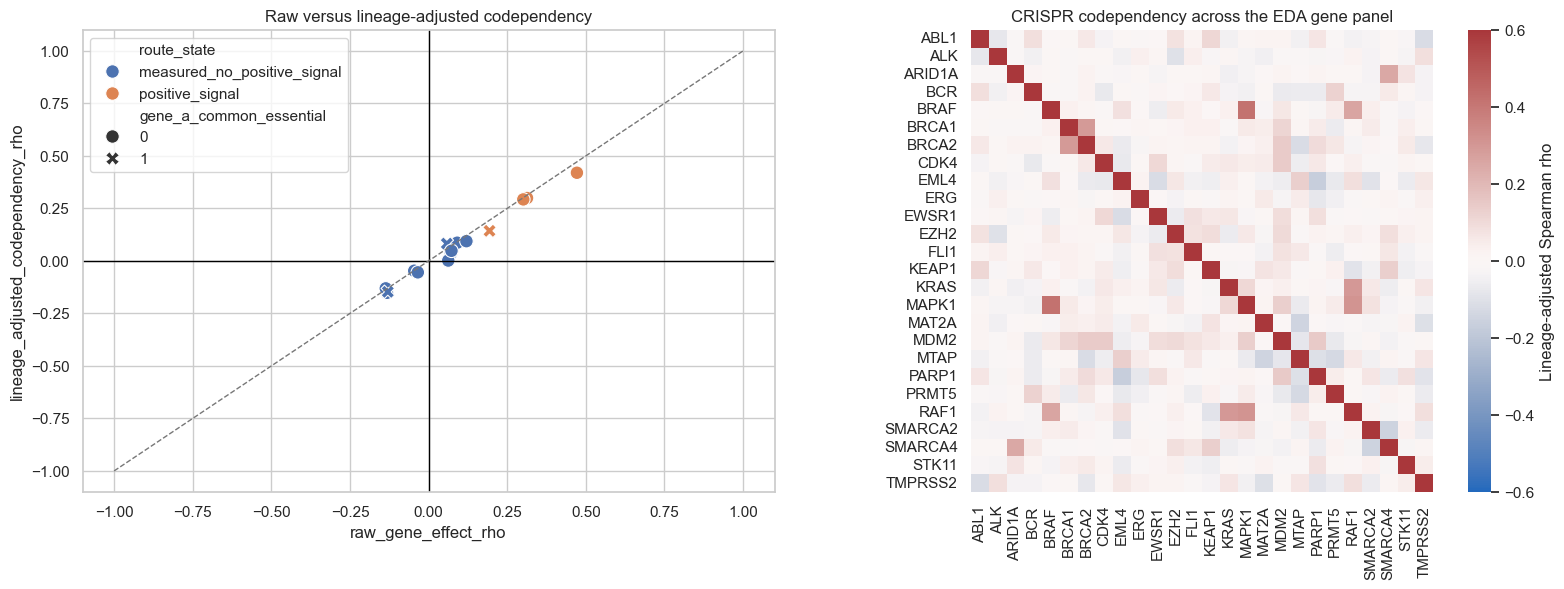

In [4]:
available_genes = gene_availability.loc[
    gene_availability['has_crispr_effect'] & gene_availability['has_crispr_dependency'], 'gene'
].tolist()
effect_columns = gene_lookup.loc[available_genes, 'crispr_effect_column'].to_dict()
dependency_columns = gene_lookup.loc[available_genes, 'crispr_dependency_column'].to_dict()

effect = pd.read_csv(PATHS['effect'], usecols=['Unnamed: 0', *effect_columns.values()]).rename(
    columns={'Unnamed: 0': 'model_id', **{v: k for k, v in effect_columns.items()}}
).set_index('model_id')
dependency = pd.read_csv(PATHS['dependency'], usecols=['Unnamed: 0', *dependency_columns.values()]).rename(
    columns={'Unnamed: 0': 'model_id', **{v: k for k, v in dependency_columns.items()}}
).set_index('model_id')

assert effect.index.is_unique and dependency.index.is_unique
assert effect.index.equals(dependency.index)

common_essential = gene_lookup['is_crispr_common_essential'].fillna(0).astype(int).to_dict()


def lineage_adjusted_pair_correlation(gene_a: str, gene_b: str, matrix: pd.DataFrame) -> dict:
    if gene_a not in matrix or gene_b not in matrix:
        return {'models': 0, 'raw_rho': np.nan, 'adjusted_models': 0, 'adjusted_rho': np.nan}
    frame = matrix[[gene_a, gene_b]].copy()
    frame['lineage'] = lineage_lookup.reindex(frame.index)
    frame = frame.dropna()
    raw_rho = frame[gene_a].corr(frame[gene_b], method='spearman') if len(frame) >= 30 else np.nan
    keep = frame.groupby('lineage')[gene_a].transform('size').ge(15)
    adjusted = frame.loc[keep].copy()
    if len(adjusted) >= 30:
        adjusted[[gene_a, gene_b]] = adjusted[[gene_a, gene_b]] - adjusted.groupby('lineage')[[gene_a, gene_b]].transform('median')
        adjusted_rho = adjusted[gene_a].corr(adjusted[gene_b], method='spearman')
    else:
        adjusted_rho = np.nan
    return {'models': len(frame), 'raw_rho': raw_rho, 'adjusted_models': len(adjusted), 'adjusted_rho': adjusted_rho}


codependency_rows = []
for row in pair_catalog.itertuples(index=False):
    effect_stats = lineage_adjusted_pair_correlation(row.gene_a, row.gene_b, effect)
    probability_stats = lineage_adjusted_pair_correlation(row.gene_a, row.gene_b, dependency)
    if pd.isna(effect_stats['adjusted_rho']):
        state = 'not_measured_or_insufficient'
    elif effect_stats['adjusted_rho'] >= 0.10:
        state = 'positive_signal'
    else:
        state = 'measured_no_positive_signal'
    codependency_rows.append({
        'pair_id': row.pair_id,
        'gene_a': row.gene_a,
        'gene_b': row.gene_b,
        'codependency_models': effect_stats['models'],
        'raw_gene_effect_rho': effect_stats['raw_rho'],
        'lineage_adjusted_models': effect_stats['adjusted_models'],
        'lineage_adjusted_codependency_rho': effect_stats['adjusted_rho'],
        'dependency_probability_rho': probability_stats['adjusted_rho'],
        'gene_a_common_essential': common_essential.get(row.gene_a, 0),
        'gene_b_common_essential': common_essential.get(row.gene_b, 0),
        'route_state': state,
    })
codependency_route = pd.DataFrame(codependency_rows)
display(codependency_route.sort_values('lineage_adjusted_codependency_rho', ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.scatterplot(data=codependency_route, x='raw_gene_effect_rho', y='lineage_adjusted_codependency_rho',
                hue='route_state', style='gene_a_common_essential', s=95, ax=axes[0])
axes[0].axhline(0, color='black', linewidth=1); axes[0].axvline(0, color='black', linewidth=1)
axes[0].plot([-1, 1], [-1, 1], linestyle='--', color='#777777', linewidth=1)
axes[0].set_title('Raw versus lineage-adjusted codependency')

panel_effect = effect[available_genes].copy()
panel_effect['lineage'] = lineage_lookup.reindex(panel_effect.index)
keep = panel_effect.groupby('lineage')[available_genes[0]].transform('size').ge(15)
panel_adjusted = panel_effect.loc[keep].copy()
panel_adjusted[available_genes] = panel_adjusted[available_genes] - panel_adjusted.groupby('lineage')[available_genes].transform('median')
correlation_matrix = panel_adjusted[available_genes].corr(method='spearman')
sns.heatmap(correlation_matrix, cmap='vlag', center=0, vmin=-0.6, vmax=0.6, square=True,
            cbar_kws={'label': 'Lineage-adjusted Spearman rho'}, ax=axes[1])
axes[1].set_title('CRISPR codependency across the EDA gene panel')
plt.tight_layout(); plt.show()

### What this means for the project

A positive codependency value means the two knockout profiles rise and fall together across cell lines. Subtracting lineage medians asks whether that relationship remains after broad tissue effects are reduced. For dashboard state labels, this notebook calls `rho >= 0.10` a positive exploratory signal; the continuous rho remains the real feature and the threshold must be validated later. Codependency can support a shared-function explanation, but it does not say which gene acts first and it does not prove physical binding. A common-essential warning is shown because two genes required by almost every cell can correlate for general fitness reasons rather than a selective cancer vulnerability.

## 4. Directional conditional-dependency route

Conditional dependency asks a different question: **does a measurable state of Gene A make cells more dependent on Gene B?** We test both directions for every pair and keep four definitions separate:

- damaging or driver-like mutation versus no such recorded event;
- absolute copy-number loss (`CN <= 1`) versus near-diploid (`1 < CN < 4`);
- absolute copy-number gain (`CN >= 4`) versus near-diploid;
- top versus bottom RNA-expression quintile calculated within sufficiently large lineages.

Positive dependency shifts mean the context group has a more negative Gene B CRISPR gene effect and is therefore more dependent on Gene B.

,pair_id,directional_pair_id,context_gene,target_gene,context_type,context_definition,route_state,is_common_essential_target,context_models,reference_models,dependency_shift,dependency_rank_effect,dependency_probability_shift,lineage_adjusted_models,lineage_adjusted_context_models,lineage_adjusted_reference_models,lineage_adjusted_dependency_shift
104,BRAF--MAPK1,BRAF -> MAPK1,BRAF,MAPK1,Mutation,Damaging or driver-like vs no such recorded event,positive_signal,0,98,1080,0.448657,0.621466,0.603297,1143,90,1053,0.187003
103,CDK4--MDM2,MDM2 -> CDK4,MDM2,CDK4,RNA high,Within-lineage top vs bottom expression quintile,positive_signal,1,222,222,0.088771,0.143901,0.090493,340,170,170,0.111855
41,SMARCA2--SMARCA4,SMARCA2 -> SMARCA4,SMARCA2,SMARCA4,Copy-number loss,CN <= 1 vs 1 < CN < 4,positive_signal,0,96,647,0.173016,0.243399,0.259821,685,87,598,0.109685
64,KRAS--RAF1,KRAS -> RAF1,KRAS,RAF1,Mutation,Damaging or driver-like vs no such recorded event,positive_signal,0,176,1002,0.205490,0.374240,0.228858,1143,173,970,0.103703
44,SMARCA2--SMARCA4,SMARCA4 -> SMARCA2,SMARCA4,SMARCA2,Mutation,Damaging or driver-like vs no such recorded event,positive_signal,0,64,1114,0.107650,0.433432,0.023159,1143,61,1082,0.098584
102,CDK4--MDM2,MDM2 -> CDK4,MDM2,CDK4,Copy-number gain,CN >= 4 vs 1 < CN < 4,positive_signal,1,296,648,0.117842,0.228166,0.133981,902,285,617,0.087280
48,BRCA1--PARP1,BRCA1 -> PARP1,BRCA1,PARP1,Mutation,Damaging or driver-like vs no such recorded event,positive_signal,0,21,1157,0.047145,0.271186,0.054422,1143,21,1122,0.083418
73,MTAP--PRMT5,MTAP -> PRMT5,MTAP,PRMT5,Copy-number loss,CN <= 1 vs 1 < CN < 4,positive_signal,1,305,517,0.062779,0.196829,0.008690,775,297,478,0.065392
1,ABL1--BCR,ABL1 -> BCR,ABL1,BCR,Copy-number loss,CN <= 1 vs 1 < CN < 4,positive_signal,0,11,640,0.070584,0.263352,0.010918,600,10,590,0.063218
45,SMARCA2--SMARCA4,SMARCA4 -> SMARCA2,SMARCA4,SMARCA2,Copy-number loss,CN <= 1 vs 1 < CN < 4,positive_signal,0,24,715,0.047709,0.314569,0.010702,691,23,668,0.056626


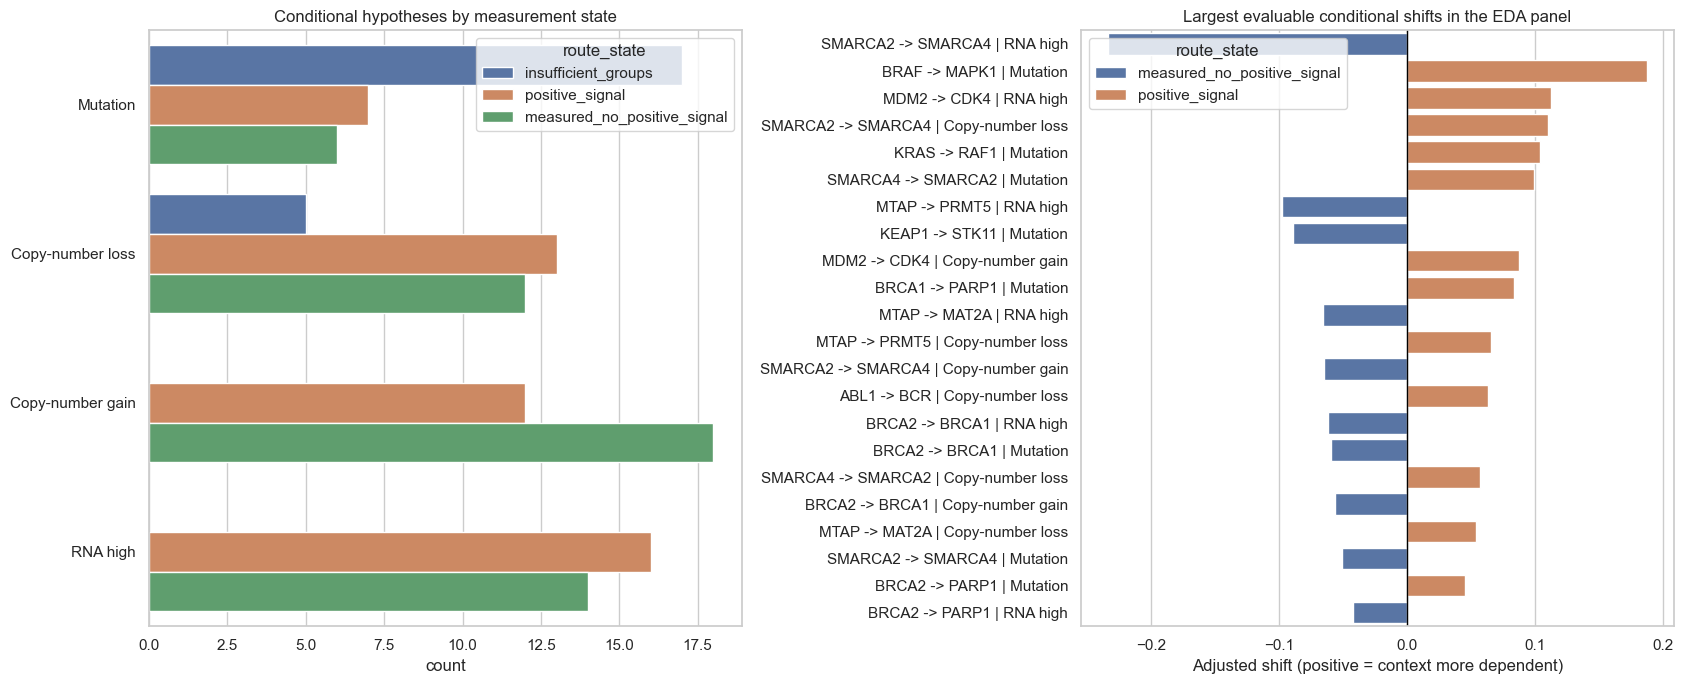

In [5]:
context_genes = panel_genes
expression_genes = gene_availability.loc[gene_availability['has_expression'], 'gene'].tolist()
copy_genes = gene_availability.loc[gene_availability['has_copy_number'], 'gene'].tolist()

expression_columns = gene_lookup.loc[expression_genes, 'expression_column'].to_dict()
copy_columns = gene_lookup.loc[copy_genes, 'copy_number_column'].to_dict()
expression = pd.read_csv(PATHS['expression'], usecols=['model_id', *expression_columns.values()]).rename(
    columns={v: k for k, v in expression_columns.items()}
).set_index('model_id')
copy_number = pd.read_csv(PATHS['copy_number'], usecols=['Unnamed: 0', *copy_columns.values()]).rename(
    columns={'Unnamed: 0': 'model_id', **{v: k for k, v in copy_columns.items()}}
).set_index('model_id')

mutations['damaging_or_driver'] = (
    mutations['has_likely_lof'].eq(1)
    | mutations['highest_vep_impact'].eq('HIGH')
    | mutations[['has_hotspot', 'has_oncogene_high_impact', 'has_tumor_suppressor_high_impact']].eq(1).any(axis=1)
)

crispr_ids = set(effect.index)
mutation_universe = crispr_ids & set(master.loc[master['has_mutation_assay'].eq(1), 'model_id'])
copy_universe = crispr_ids & set(master.loc[master['has_absolute_copy_number'].eq(1), 'model_id']) & set(copy_number.index)
rna_universe = crispr_ids & set(master.loc[master['has_expression'].eq(1), 'model_id']) & set(expression.index)


def rank_biserial(left: np.ndarray, right: np.ndarray) -> float:
    left = np.asarray(left, dtype=float)
    right = np.asarray(right, dtype=float)
    if len(left) == 0 or len(right) == 0:
        return np.nan
    ranks = rankdata(np.concatenate([left, right]))
    u_left = ranks[:len(left)].sum() - len(left) * (len(left) + 1) / 2
    return 2 * u_left / (len(left) * len(right)) - 1


def dependency_comparison(target_gene: str, context_ids: set, reference_ids: set, allowed_ids: set) -> dict:
    if target_gene not in effect or target_gene not in dependency:
        return {
            'context_models': 0, 'reference_models': 0, 'dependency_shift': np.nan,
            'dependency_rank_effect': np.nan, 'dependency_probability_shift': np.nan,
            'lineage_adjusted_models': 0, 'lineage_adjusted_context_models': 0,
            'lineage_adjusted_reference_models': 0, 'lineage_adjusted_dependency_shift': np.nan,
        }
    available = set(effect.index) & set(dependency.index) & set(allowed_ids)
    context = sorted(set(context_ids) & available)
    reference = sorted(set(reference_ids) & available)
    selected = context + reference
    frame = pd.DataFrame({
        'gene_effect': effect.loc[selected, target_gene],
        'dependency_probability': dependency.loc[selected, target_gene],
        'lineage': lineage_lookup.reindex(selected),
        'group': ['Context'] * len(context) + ['Reference'] * len(reference),
    }).dropna()
    context_effect = frame.loc[frame['group'].eq('Context'), 'gene_effect'].to_numpy()
    reference_effect = frame.loc[frame['group'].eq('Reference'), 'gene_effect'].to_numpy()
    context_probability = frame.loc[frame['group'].eq('Context'), 'dependency_probability'].to_numpy()
    reference_probability = frame.loc[frame['group'].eq('Reference'), 'dependency_probability'].to_numpy()

    keep = frame.groupby('lineage')['gene_effect'].transform('size').ge(15)
    adjusted = frame.loc[keep].copy()
    adjusted['effect_residual'] = adjusted['gene_effect'] - adjusted.groupby('lineage')['gene_effect'].transform('median')
    adjusted_context = adjusted.loc[adjusted['group'].eq('Context'), 'effect_residual'].to_numpy()
    adjusted_reference = adjusted.loc[adjusted['group'].eq('Reference'), 'effect_residual'].to_numpy()
    usable = len(adjusted_context) >= 10 and len(adjusted_reference) >= 10 and len(adjusted) >= 30

    return {
        'context_models': len(context_effect),
        'reference_models': len(reference_effect),
        'dependency_shift': np.median(reference_effect) - np.median(context_effect) if len(context_effect) and len(reference_effect) else np.nan,
        'dependency_rank_effect': -rank_biserial(context_effect, reference_effect),
        'dependency_probability_shift': np.median(context_probability) - np.median(reference_probability) if len(context_probability) and len(reference_probability) else np.nan,
        'lineage_adjusted_models': len(adjusted),
        'lineage_adjusted_context_models': len(adjusted_context),
        'lineage_adjusted_reference_models': len(adjusted_reference),
        'lineage_adjusted_dependency_shift': np.median(adjusted_reference) - np.median(adjusted_context) if usable else np.nan,
    }


def within_lineage_extremes(values: pd.Series, allowed_ids: set, lower_q: float = 0.2, upper_q: float = 0.8) -> tuple[set, set]:
    ids = sorted(set(values.index) & set(allowed_ids))
    frame = pd.DataFrame({'value': values.reindex(ids), 'lineage': lineage_lookup.reindex(ids)}).dropna()
    keep = frame.groupby('lineage')['value'].transform('size').ge(15)
    frame = frame.loc[keep].copy()
    frame['lower'] = frame.groupby('lineage')['value'].transform(lambda s: s.quantile(lower_q))
    frame['upper'] = frame.groupby('lineage')['value'].transform(lambda s: s.quantile(upper_q))
    low = set(frame.index[frame['value'].le(frame['lower'])])
    high = set(frame.index[frame['value'].ge(frame['upper'])])
    overlap = low & high
    return high - overlap, low - overlap


conditional_rows = []
for pair in pair_catalog.itertuples(index=False):
    for context_gene, target_gene in [(pair.gene_a, pair.gene_b), (pair.gene_b, pair.gene_a)]:
        directional_id = f'{context_gene} -> {target_gene}'
        gene_events = mutations.loc[mutations['hugo_symbol'].eq(context_gene)]
        mutation_context = set(gene_events.loc[gene_events['damaging_or_driver'], 'model_id']) & mutation_universe
        definitions = [
            ('Mutation', 'Damaging or driver-like vs no such recorded event', mutation_context, mutation_universe - mutation_context, mutation_universe),
        ]

        if context_gene in copy_number:
            cn = copy_number.loc[sorted(copy_universe), context_gene].dropna()
            near_diploid = set(cn.index[cn.gt(1) & cn.lt(4)])
            definitions.extend([
                ('Copy-number loss', 'CN <= 1 vs 1 < CN < 4', set(cn.index[cn.le(1)]), near_diploid, copy_universe),
                ('Copy-number gain', 'CN >= 4 vs 1 < CN < 4', set(cn.index[cn.ge(4)]), near_diploid, copy_universe),
            ])
        else:
            definitions.extend([
                ('Copy-number loss', 'CN <= 1 vs 1 < CN < 4', set(), set(), set()),
                ('Copy-number gain', 'CN >= 4 vs 1 < CN < 4', set(), set(), set()),
            ])

        if context_gene in expression:
            high, low = within_lineage_extremes(expression[context_gene], rna_universe)
            definitions.append(('RNA high', 'Within-lineage top vs bottom expression quintile', high, low, rna_universe))
        else:
            definitions.append(('RNA high', 'Within-lineage top vs bottom expression quintile', set(), set(), set()))

        for context_type, definition, context_ids, reference_ids, allowed_ids in definitions:
            stats = dependency_comparison(target_gene, context_ids, reference_ids, allowed_ids)
            shift = stats['lineage_adjusted_dependency_shift']
            if not allowed_ids or target_gene not in effect:
                state = 'not_measured'
            elif pd.isna(shift):
                state = 'insufficient_groups'
            elif shift > 0:
                state = 'positive_signal'
            else:
                state = 'measured_no_positive_signal'
            conditional_rows.append({
                'pair_id': pair.pair_id,
                'directional_pair_id': directional_id,
                'context_gene': context_gene,
                'target_gene': target_gene,
                'context_type': context_type,
                'context_definition': definition,
                'route_state': state,
                'is_common_essential_target': common_essential.get(target_gene, 0),
                **stats,
            })

conditional_route = pd.DataFrame(conditional_rows)
conditional_evaluable = conditional_route.loc[conditional_route['lineage_adjusted_dependency_shift'].notna()].copy()
display(conditional_evaluable.sort_values('lineage_adjusted_dependency_shift', ascending=False).head(30))

fig, axes = plt.subplots(1, 2, figsize=(17, 7))
sns.countplot(data=conditional_route, y='context_type', hue='route_state', ax=axes[0])
axes[0].set_title('Conditional hypotheses by measurement state'); axes[0].set_ylabel('')
top_conditional = conditional_evaluable.reindex(
    conditional_evaluable['lineage_adjusted_dependency_shift'].abs().sort_values(ascending=False).index
).head(22).copy()
top_conditional['hypothesis'] = top_conditional['directional_pair_id'] + ' | ' + top_conditional['context_type']
sns.barplot(data=top_conditional, x='lineage_adjusted_dependency_shift', y='hypothesis',
            hue='route_state', dodge=False, ax=axes[1])
axes[1].axvline(0, color='black', linewidth=1)
axes[1].set_title('Largest evaluable conditional shifts in the EDA panel')
axes[1].set_xlabel('Adjusted shift (positive = context more dependent)'); axes[1].set_ylabel('')
plt.tight_layout(); plt.show()

### What this means for the project

Conditional dependency is the route most closely related to a selective vulnerability. For example, `ARID1A -> EZH2` asks whether cells with damaging ARID1A events are more harmed when EZH2 is knocked out. Reversing the arrow asks a different biological question and is therefore stored separately. A positive shift is useful evidence only when both groups are large enough and the direction survives lineage adjustment. Mutation, loss, gain, and RNA-high results must not be collapsed because each describes a different cellular state.

## 5. Route-preserving gene-pair evidence model

The long table below is the main modelling contract. A pair can have one fusion record, one codependency record, and several directional conditional records. `metric_name` and `metric_value` are always carried together because a fusion recurrence percentage, a correlation, and a conditional shift are not mathematically interchangeable.

In [6]:
fusion_long = fusion_route.assign(
    route_family='direct_fusion',
    directional_pair_id=pd.NA,
    context_type=pd.NA,
    context_definition=pd.NA,
    metric_name='direct_fusion_model_fraction_pct',
    metric_value=fusion_route['direct_fusion_model_fraction_pct'],
    numerator=fusion_route['models_with_direct_fusion'],
    denominator=fusion_route['fusion_assayed_models'],
)[['pair_id', 'route_family', 'route_state', 'directional_pair_id', 'context_type', 'context_definition',
   'metric_name', 'metric_value', 'numerator', 'denominator']]

codependency_long = codependency_route.assign(
    route_family='crispr_codependency',
    directional_pair_id=pd.NA,
    context_type=pd.NA,
    context_definition=pd.NA,
    metric_name='lineage_adjusted_codependency_rho',
    metric_value=codependency_route['lineage_adjusted_codependency_rho'],
    numerator=pd.NA,
    denominator=codependency_route['lineage_adjusted_models'],
)[['pair_id', 'route_family', 'route_state', 'directional_pair_id', 'context_type', 'context_definition',
   'metric_name', 'metric_value', 'numerator', 'denominator']]

conditional_long = conditional_route.assign(
    route_family='conditional_dependency',
    metric_name='lineage_adjusted_dependency_shift',
    metric_value=conditional_route['lineage_adjusted_dependency_shift'],
    numerator=conditional_route['lineage_adjusted_context_models'],
    denominator=conditional_route['lineage_adjusted_context_models'] + conditional_route['lineage_adjusted_reference_models'],
)[['pair_id', 'route_family', 'route_state', 'directional_pair_id', 'context_type', 'context_definition',
   'metric_name', 'metric_value', 'numerator', 'denominator']]

pair_route_long = pd.concat([fusion_long, codependency_long, conditional_long], ignore_index=True)
display(pair_route_long.head(30))
display(pair_route_long.groupby(['route_family', 'route_state']).size().rename('records').reset_index())

assert set(pair_route_long['route_family']) == {'direct_fusion', 'crispr_codependency', 'conditional_dependency'}
assert pair_route_long.loc[pair_route_long['route_family'].eq('conditional_dependency'), 'directional_pair_id'].notna().all()
assert pair_route_long.loc[~pair_route_long['route_family'].eq('conditional_dependency'), 'directional_pair_id'].isna().all()

,pair_id,route_family,route_state,directional_pair_id,context_type,context_definition,metric_name,metric_value,numerator,denominator
0,ABL1--BCR,direct_fusion,direct_pair_observed,NaN,NaN,NaN,direct_fusion_model_fraction_pct,1.435407,24,1672
1,ALK--EML4,direct_fusion,direct_pair_observed,NaN,NaN,NaN,direct_fusion_model_fraction_pct,0.418660,7,1672
2,ERG--TMPRSS2,direct_fusion,direct_pair_observed,NaN,NaN,NaN,direct_fusion_model_fraction_pct,0.119617,2,1672
3,EWSR1--FLI1,direct_fusion,direct_pair_observed,NaN,NaN,NaN,direct_fusion_model_fraction_pct,1.196172,20,1672
4,ARID1A--EZH2,direct_fusion,assayed_no_retained_pair_call,NaN,NaN,NaN,direct_fusion_model_fraction_pct,0.000000,0,1672
5,SMARCA2--SMARCA4,direct_fusion,assayed_no_retained_pair_call,NaN,NaN,NaN,direct_fusion_model_fraction_pct,0.000000,0,1672
6,BRCA1--PARP1,direct_fusion,assayed_no_retained_pair_call,NaN,NaN,NaN,direct_fusion_model_fraction_pct,0.000000,0,1672
7,BRCA2--PARP1,direct_fusion,assayed_no_retained_pair_call,NaN,NaN,NaN,direct_fusion_model_fraction_pct,0.000000,0,1672
8,KRAS--RAF1,direct_fusion,assayed_no_retained_pair_call,NaN,NaN,NaN,direct_fusion_model_fraction_pct,0.000000,0,1672
9,MTAP--PRMT5,direct_fusion,assayed_no_retained_pair_call,NaN,NaN,NaN,direct_fusion_model_fraction_pct,0.000000,0,1672


,route_family,route_state,records
0,conditional_dependency,insufficient_groups,22
1,conditional_dependency,measured_no_positive_signal,50
2,conditional_dependency,positive_signal,48
3,crispr_codependency,measured_no_positive_signal,11
4,crispr_codependency,positive_signal,4
5,direct_fusion,assayed_no_retained_pair_call,11
6,direct_fusion,direct_pair_observed,4


### What this means for the project

This structure prevents a biologically misleading join. The routes are connected by `pair_id` for reporting, but they remain separate rows with separate units and denominators. A future model can use route-specific features, and the dashboard can trace every displayed statement back to its route record. Adding pathway databases later should add explanation fields or a fourth transparent route, not silently change these measured values.

## 6. Pair-level dashboard view without a blended score

For a compact screen, the route table can be pivoted into one row per pair. Conditional dependency has multiple valid hypotheses, so the table reports how many were evaluable and selects the largest positive adjusted shift as the **display candidate** when one exists; otherwise it shows the largest absolute measured shift. That selection rule is visible and must not be treated as a validated ranking because testing many contexts increases the chance of an extreme result.

In [7]:
conditional_counts = conditional_route.groupby('pair_id').agg(
    evaluable_conditional_hypotheses=('lineage_adjusted_dependency_shift', lambda s: int(s.notna().sum())),
    positive_conditional_signals=('route_state', lambda s: int(s.eq('positive_signal').sum())),
).reset_index()

conditional_display = conditional_evaluable.copy()
conditional_display['absolute_shift'] = conditional_display['lineage_adjusted_dependency_shift'].abs()
conditional_display['positive_priority'] = conditional_display['lineage_adjusted_dependency_shift'].gt(0).astype(int)
conditional_display['selection_value'] = np.where(
    conditional_display['positive_priority'].eq(1),
    conditional_display['lineage_adjusted_dependency_shift'],
    conditional_display['absolute_shift'],
)
conditional_display = (
    conditional_display.sort_values(
        ['pair_id', 'positive_priority', 'selection_value'], ascending=[True, False, False]
    )
    .drop_duplicates('pair_id')
    .rename(columns={
        'directional_pair_id': 'conditional_display_direction',
        'context_type': 'conditional_display_context',
        'context_definition': 'conditional_display_definition',
        'lineage_adjusted_dependency_shift': 'conditional_display_shift',
        'lineage_adjusted_context_models': 'conditional_display_context_models',
        'lineage_adjusted_reference_models': 'conditional_display_reference_models',
        'route_state': 'conditional_display_state',
    })
)

dashboard_pair_summary = (
    pair_catalog[['pair_id', 'gene_a', 'gene_b', 'example_reason']]
    .merge(fusion_route[[
        'pair_id', 'route_state', 'models_with_direct_fusion', 'fusion_assayed_models',
        'direct_fusion_model_fraction_pct', 'total_junction_reads', 'total_spanning_fragments',
        'max_ffpm', 'models_with_large_anchor_support'
    ]].rename(columns={'route_state': 'fusion_route_state'}), on='pair_id', how='left', validate='one_to_one')
    .merge(codependency_route[[
        'pair_id', 'route_state', 'codependency_models', 'lineage_adjusted_models',
        'raw_gene_effect_rho', 'lineage_adjusted_codependency_rho', 'dependency_probability_rho',
        'gene_a_common_essential', 'gene_b_common_essential'
    ]].rename(columns={'route_state': 'codependency_route_state'}), on='pair_id', how='left', validate='one_to_one')
    .merge(conditional_counts, on='pair_id', how='left', validate='one_to_one')
    .merge(conditional_display[[
        'pair_id', 'conditional_display_direction', 'conditional_display_context',
        'conditional_display_definition', 'conditional_display_shift',
        'conditional_display_context_models', 'conditional_display_reference_models',
        'conditional_display_state'
    ]], on='pair_id', how='left', validate='one_to_one')
)

def positive_route_labels(row) -> str:
    labels = []
    if row['fusion_route_state'] == 'direct_pair_observed':
        labels.append('direct fusion')
    if row['codependency_route_state'] == 'positive_signal':
        labels.append('CRISPR codependency')
    if row['positive_conditional_signals'] > 0:
        labels.append('conditional dependency')
    return ' | '.join(labels) if labels else 'none in this EDA'


dashboard_pair_summary['routes_with_positive_signal'] = dashboard_pair_summary.apply(positive_route_labels, axis=1)
display(dashboard_pair_summary)

dashboard_columns = [
    'pair_id', 'routes_with_positive_signal',
    'models_with_direct_fusion', 'fusion_assayed_models', 'total_junction_reads',
    'lineage_adjusted_codependency_rho', 'lineage_adjusted_models',
    'conditional_display_direction', 'conditional_display_context', 'conditional_display_shift',
    'conditional_display_context_models', 'conditional_display_reference_models',
]
display(dashboard_pair_summary[dashboard_columns])

,pair_id,gene_a,gene_b,example_reason,fusion_route_state,models_with_direct_fusion,fusion_assayed_models,direct_fusion_model_fraction_pct,total_junction_reads,total_spanning_fragments,max_ffpm,models_with_large_anchor_support,codependency_route_state,codependency_models,lineage_adjusted_models,raw_gene_effect_rho,lineage_adjusted_codependency_rho,dependency_probability_rho,gene_a_common_essential,gene_b_common_essential,evaluable_conditional_hypotheses,positive_conditional_signals,conditional_display_direction,conditional_display_context,conditional_display_definition,conditional_display_shift,conditional_display_context_models,conditional_display_reference_models,conditional_display_state,routes_with_positive_signal
0,ABL1--BCR,ABL1,BCR,Direct fusion example,direct_pair_observed,24,1672,1.435407,3768,3134,7.9447,24,measured_no_positive_signal,1178,1143,0.090996,0.086601,0.125697,0,0,6,6,ABL1 -> BCR,Copy-number loss,CN <= 1 vs 1 < CN < 4,0.063218,10,590,positive_signal,direct fusion | conditional dependency
1,ALK--EML4,ALK,EML4,Direct fusion example,direct_pair_observed,7,1672,0.418660,331,615,2.0730,7,measured_no_positive_signal,1178,1143,-0.045652,-0.046801,0.028941,0,0,7,4,EML4 -> ALK,Copy-number gain,CN >= 4 vs 1 < CN < 4,0.011513,264,619,positive_signal,direct fusion | conditional dependency
2,ERG--TMPRSS2,ERG,TMPRSS2,Direct fusion example,direct_pair_observed,2,1672,0.119617,413,133,2.5995,2,measured_no_positive_signal,1178,1143,0.071004,0.037018,0.116236,0,0,6,1,ERG -> TMPRSS2,Copy-number loss,CN <= 1 vs 1 < CN < 4,0.009776,17,655,positive_signal,direct fusion | conditional dependency
3,EWSR1--FLI1,EWSR1,FLI1,Direct fusion example,direct_pair_observed,20,1672,1.196172,3415,2752,7.1792,20,measured_no_positive_signal,1178,1143,0.057887,0.082484,0.035690,1,0,6,2,FLI1 -> EWSR1,Copy-number gain,CN >= 4 vs 1 < CN < 4,0.011418,247,597,positive_signal,direct fusion | conditional dependency
4,ARID1A--EZH2,ARID1A,EZH2,Chromatin conditional-dependency hypothesis,assayed_no_retained_pair_call,0,1672,0.000000,0,0,0.0000,0,measured_no_positive_signal,1178,1143,0.062477,0.001629,0.025385,0,0,8,3,ARID1A -> EZH2,Mutation,Damaging or driver-like vs no such recorded event,0.033661,116,1027,positive_signal,conditional dependency
5,SMARCA2--SMARCA4,SMARCA2,SMARCA4,Paralog conditional-dependency hypothesis,assayed_no_retained_pair_call,0,1672,0.000000,0,0,0.0000,0,measured_no_positive_signal,1178,1143,-0.132322,-0.151957,-0.145294,0,0,8,3,SMARCA2 -> SMARCA4,Copy-number loss,CN <= 1 vs 1 < CN < 4,0.109685,87,598,positive_signal,conditional dependency
6,BRCA1--PARP1,BRCA1,PARP1,DNA-repair conditional-dependency hypothesis,assayed_no_retained_pair_call,0,1672,0.000000,0,0,0.0000,0,measured_no_positive_signal,1178,1143,0.072755,0.048120,0.079930,0,0,6,2,BRCA1 -> PARP1,Mutation,Damaging or driver-like vs no such recorded event,0.083418,21,1122,positive_signal,conditional dependency
7,BRCA2--PARP1,BRCA2,PARP1,DNA-repair conditional-dependency hypothesis,assayed_no_retained_pair_call,0,1672,0.000000,0,0,0.0000,0,measured_no_positive_signal,1178,1143,0.120243,0.093899,0.102112,0,0,6,1,BRCA2 -> PARP1,Mutation,Damaging or driver-like vs no such recorded event,0.045164,34,1109,positive_signal,conditional dependency
8,KRAS--RAF1,KRAS,RAF1,Signalling conditional-dependency hypothesis,assayed_no_retained_pair_call,0,1672,0.000000,0,0,0.0000,0,positive_signal,1178,1143,0.313018,0.299518,0.257821,0,0,7,5,KRAS -> RAF1,Mutation,Damaging or driver-like vs no such recorded event,0.103703,173,970,positive_signal,CRISPR codependency | conditional dependency
9,MTAP--PRMT5,MTAP,PRMT5,Copy-loss conditional-dependency hypothesis,assayed_no_retained_pair_call,0,1672,0.000000,0,0,0.0000,0,measured_no_positive_signal,1178,1143,-0.136174,-0.130745,-0.087783,0,1,6,3,MTAP -> PRMT5,Copy-number loss,CN <= 1 vs 1 < CN < 4,0.065392,297,478,positive_signal,conditional dependency


,pair_id,routes_with_positive_signal,models_with_direct_fusion,fusion_assayed_models,total_junction_reads,lineage_adjusted_codependency_rho,lineage_adjusted_models,conditional_display_direction,conditional_display_context,conditional_display_shift,conditional_display_context_models,conditional_display_reference_models
0,ABL1--BCR,direct fusion | conditional dependency,24,1672,3768,0.086601,1143,ABL1 -> BCR,Copy-number loss,0.063218,10,590
1,ALK--EML4,direct fusion | conditional dependency,7,1672,331,-0.046801,1143,EML4 -> ALK,Copy-number gain,0.011513,264,619
2,ERG--TMPRSS2,direct fusion | conditional dependency,2,1672,413,0.037018,1143,ERG -> TMPRSS2,Copy-number loss,0.009776,17,655
3,EWSR1--FLI1,direct fusion | conditional dependency,20,1672,3415,0.082484,1143,FLI1 -> EWSR1,Copy-number gain,0.011418,247,597
4,ARID1A--EZH2,conditional dependency,0,1672,0,0.001629,1143,ARID1A -> EZH2,Mutation,0.033661,116,1027
5,SMARCA2--SMARCA4,conditional dependency,0,1672,0,-0.151957,1143,SMARCA2 -> SMARCA4,Copy-number loss,0.109685,87,598
6,BRCA1--PARP1,conditional dependency,0,1672,0,0.048120,1143,BRCA1 -> PARP1,Mutation,0.083418,21,1122
7,BRCA2--PARP1,conditional dependency,0,1672,0,0.093899,1143,BRCA2 -> PARP1,Mutation,0.045164,34,1109
8,KRAS--RAF1,CRISPR codependency | conditional dependency,0,1672,0,0.299518,1143,KRAS -> RAF1,Mutation,0.103703,173,970
9,MTAP--PRMT5,conditional dependency,0,1672,0,-0.130745,1143,MTAP -> PRMT5,Copy-number loss,0.065392,297,478


### What this means for the project

This is the appropriate input to a white-box dashboard. A user can see, for example, that a pair has a direct fusion call in a stated number of fusion-assayed models, a lineage-adjusted CRISPR correlation across another stated cohort, and a directional conditional shift with two group sizes. `routes_with_positive_signal` is a readable list, not a vote, probability, or confidence score. Calibration against an external answer key would be required before presenting any “percentage likely” output.

## 7. Visual comparison of routes

The three panels deliberately keep their own x-axis units. Placing all three values in one heatmap or summing normalised values would make unlike biology look directly comparable.

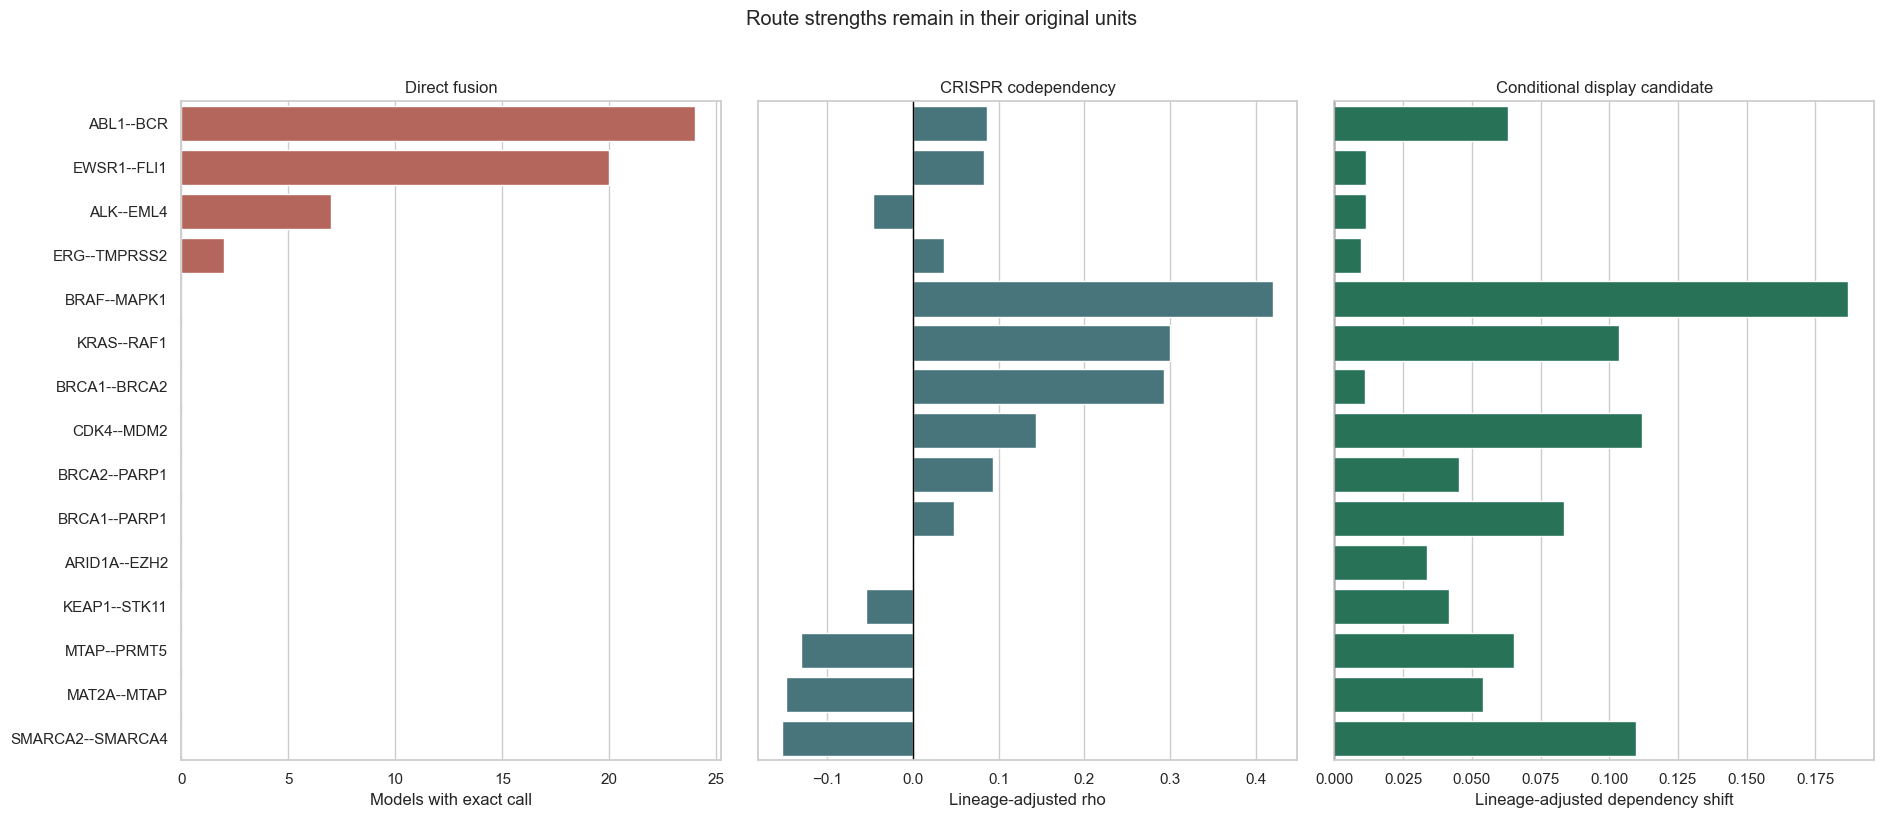

In [8]:
plot_order = dashboard_pair_summary.sort_values(
    ['models_with_direct_fusion', 'lineage_adjusted_codependency_rho'], ascending=False
)['pair_id']
plot_frame = dashboard_pair_summary.set_index('pair_id').loc[plot_order].reset_index()

fig, axes = plt.subplots(1, 3, figsize=(19, 8), sharey=True)
sns.barplot(data=plot_frame, x='models_with_direct_fusion', y='pair_id', color='#c45b4d', ax=axes[0])
axes[0].set_title('Direct fusion'); axes[0].set_xlabel('Models with exact call'); axes[0].set_ylabel('')
sns.barplot(data=plot_frame, x='lineage_adjusted_codependency_rho', y='pair_id', color='#3f7c85', ax=axes[1])
axes[1].axvline(0, color='black', linewidth=1); axes[1].set_title('CRISPR codependency')
axes[1].set_xlabel('Lineage-adjusted rho'); axes[1].set_ylabel('')
sns.barplot(data=plot_frame, x='conditional_display_shift', y='pair_id', color='#1b7f5a', ax=axes[2])
axes[2].axvline(0, color='black', linewidth=1); axes[2].set_title('Conditional display candidate')
axes[2].set_xlabel('Lineage-adjusted dependency shift'); axes[2].set_ylabel('')
plt.suptitle('Route strengths remain in their original units', y=1.02)
plt.tight_layout(); plt.show()

### What this means for the project

The side-by-side view shows why a single score would hide useful biology. A fusion route may be decisive even when only a small number of models carry the event. Codependency can use hundreds of models but is indirect. Conditional dependency can be strong in a small molecular subgroup and has a direction. The dashboard should preserve these different shapes of evidence rather than rewarding whichever assay has the largest raw number.

## 8. Multi-route gene network for dashboard prototyping

The network below uses NetworkX. Nodes are genes. Red solid edges indicate a direct fusion observed in this release, blue dashed edges indicate positive lineage-adjusted codependency, and green arrows indicate the selected positive conditional direction. The network is an explanation layer over the route table; it is not an additional prediction method.

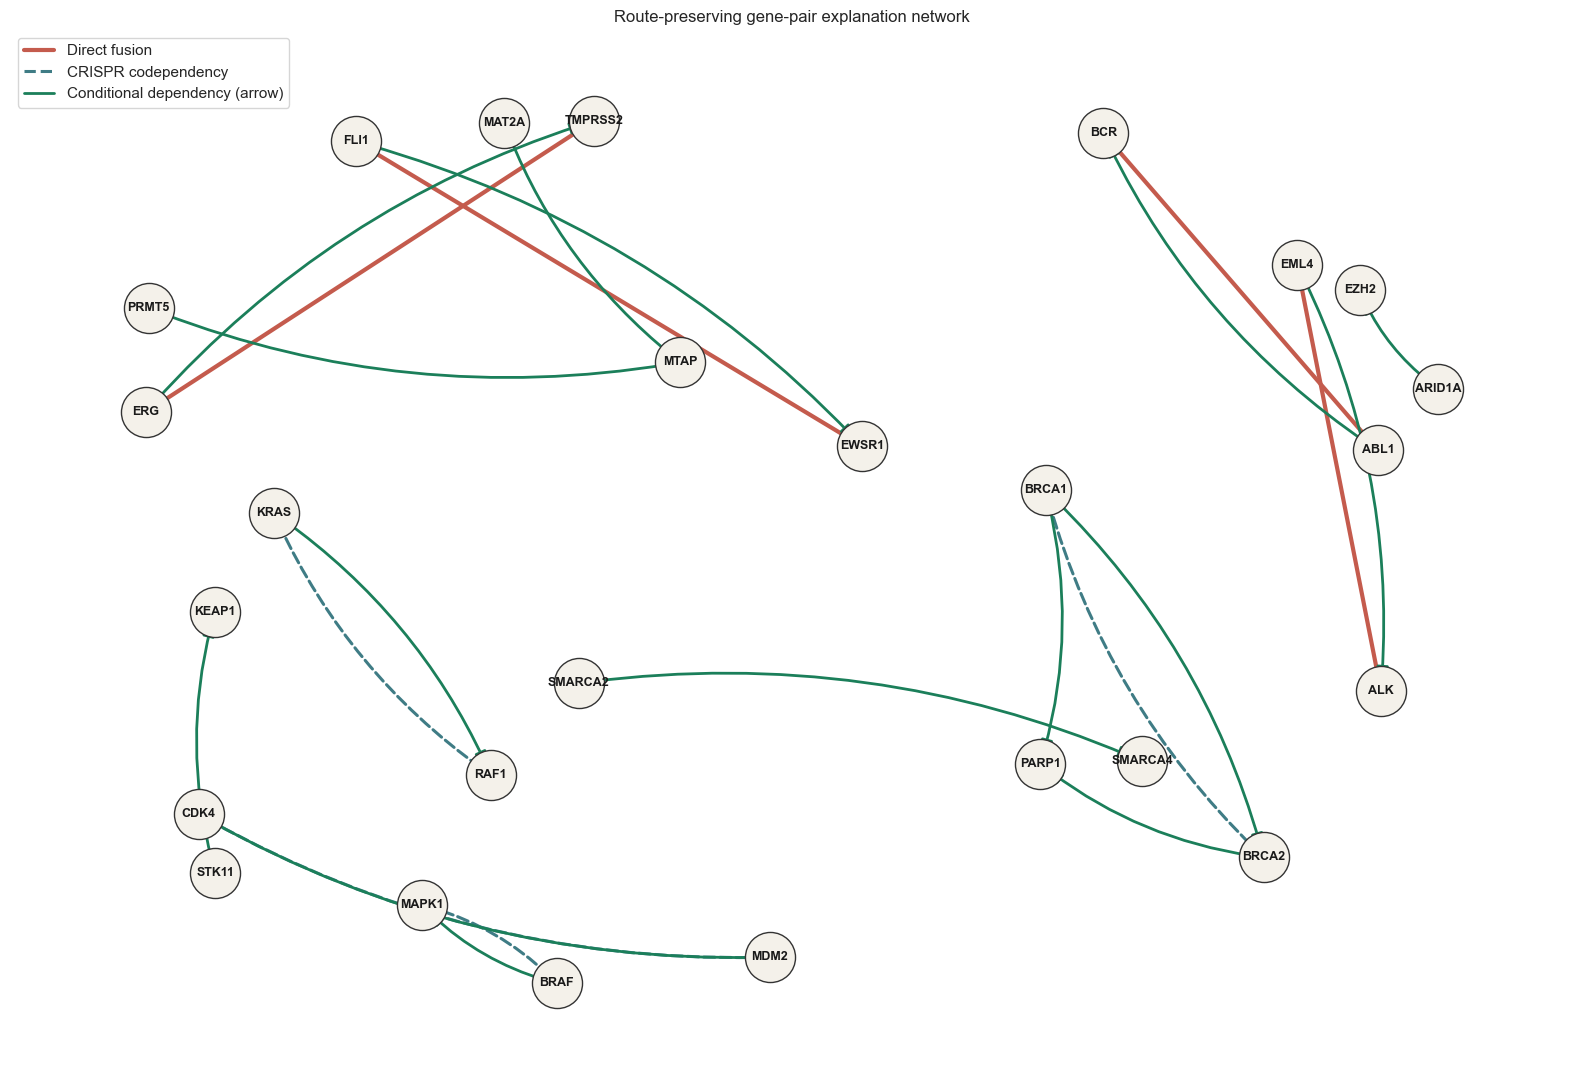

,displayed_route,edges
0,Direct fusion,4
1,Positive CRISPR codependency,4
2,Positive selected conditional direction,15


In [9]:
base_graph = nx.Graph()
base_graph.add_nodes_from(panel_genes)
for row in pair_catalog.itertuples(index=False):
    base_graph.add_edge(row.gene_a, row.gene_b)

fusion_edges = [
    (r.gene_a, r.gene_b) for r in fusion_route.itertuples(index=False)
    if r.route_state == 'direct_pair_observed'
]
codependency_edges = [
    (r.gene_a, r.gene_b) for r in codependency_route.itertuples(index=False)
    if r.route_state == 'positive_signal'
]
conditional_edges = [
    (r.context_gene, r.target_gene) for r in conditional_display.itertuples(index=False)
    if r.conditional_display_state == 'positive_signal'
]

pos = nx.spring_layout(base_graph, seed=18, k=1.15)
fig, ax = plt.subplots(figsize=(16, 11))
nx.draw_networkx_nodes(base_graph, pos, node_color='#f4f1ea', edgecolors='#333333', node_size=1300, ax=ax)
nx.draw_networkx_labels(base_graph, pos, font_size=9, font_weight='bold', ax=ax)
nx.draw_networkx_edges(base_graph, pos, edgelist=fusion_edges, edge_color='#c45b4d', width=3.0,
                       arrows=True, arrowstyle='-', connectionstyle='arc3,rad=0.00', ax=ax, label='Direct fusion')
nx.draw_networkx_edges(base_graph, pos, edgelist=codependency_edges, edge_color='#3f7c85', width=2.2,
                       style='dashed', arrows=True, arrowstyle='-', connectionstyle='arc3,rad=0.14',
                       ax=ax, label='CRISPR codependency')
conditional_graph = nx.DiGraph()
conditional_graph.add_edges_from(conditional_edges)
nx.draw_networkx_edges(conditional_graph, pos, edgelist=conditional_edges, edge_color='#1b7f5a', width=2.0,
                       arrows=True, arrowstyle='-|>', arrowsize=17, connectionstyle='arc3,rad=-0.14', ax=ax,
                       label='Conditional dependency')
legend_handles = [
    Line2D([0], [0], color='#c45b4d', linewidth=3.0, label='Direct fusion'),
    Line2D([0], [0], color='#3f7c85', linewidth=2.2, linestyle='--', label='CRISPR codependency'),
    Line2D([0], [0], color='#1b7f5a', linewidth=2.0, label='Conditional dependency (arrow)'),
]
ax.legend(handles=legend_handles, frameon=True, loc='upper left')
ax.set_title('Route-preserving gene-pair explanation network')
ax.axis('off')
plt.tight_layout(); plt.show()

network_route_counts = pd.DataFrame([
    {'displayed_route': 'Direct fusion', 'edges': len(fusion_edges)},
    {'displayed_route': 'Positive CRISPR codependency', 'edges': len(codependency_edges)},
    {'displayed_route': 'Positive selected conditional direction', 'edges': len(conditional_edges)},
])
display(network_route_counts)

### What this means for the project

This is how the final dashboard can show two genes connecting without implying that every edge means the same thing. A red fusion edge represents an observed transcript joining the genes. A blue codependency edge represents similar knockout behaviour. A green arrow represents a directional molecular-context vulnerability. Selecting an edge should open its underlying models, metric definition, denominator, and warning text.

## 9. Dashboard evidence contract

The example payload demonstrates the minimum information the interface should receive from the analysis layer. It keeps raw metrics and interpretation text together and leaves probability unset until calibration data exist.

In [10]:
example_pair_id = 'ARID1A--EZH2'
pair_row = dashboard_pair_summary.set_index('pair_id').loc[example_pair_id]
example_payload = {
    'pair_id': example_pair_id,
    'probability_likely': None,
    'probability_status': 'not calibrated',
    'routes_with_positive_signal': pair_row['routes_with_positive_signal'],
    'direct_fusion': {
        'state': pair_row['fusion_route_state'],
        'models_with_pair': int(pair_row['models_with_direct_fusion']),
        'assayed_models': int(pair_row['fusion_assayed_models']),
        'junction_reads': int(pair_row['total_junction_reads']),
    },
    'crispr_codependency': {
        'state': pair_row['codependency_route_state'],
        'lineage_adjusted_rho': float(pair_row['lineage_adjusted_codependency_rho']),
        'models': int(pair_row['lineage_adjusted_models']),
    },
    'conditional_dependency_display': {
        'direction': pair_row['conditional_display_direction'],
        'context': pair_row['conditional_display_context'],
        'lineage_adjusted_shift': float(pair_row['conditional_display_shift']),
        'context_models': int(pair_row['conditional_display_context_models']),
        'reference_models': int(pair_row['conditional_display_reference_models']),
        'selection_note': 'Largest positive evaluable shift when available; otherwise largest absolute measured shift. Full hypothesis table retained.',
    },
}
example_payload

{'pair_id': 'ARID1A--EZH2',
 'probability_likely': None,
 'probability_status': 'not calibrated',
 'routes_with_positive_signal': 'conditional dependency',
 'direct_fusion': {'state': 'assayed_no_retained_pair_call',
  'models_with_pair': 0,
  'assayed_models': 1672,
  'junction_reads': 0},
 'crispr_codependency': {'state': 'measured_no_positive_signal',
  'lineage_adjusted_rho': 0.0016287088374227702,
  'models': 1143},
 'conditional_dependency_display': {'direction': 'ARID1A -> EZH2',
  'context': 'Mutation',
  'lineage_adjusted_shift': 0.033661209407954806,
  'context_models': 116,
  'reference_models': 1027,
  'selection_note': 'Largest positive evaluable shift when available; otherwise largest absolute measured shift. Full hypothesis table retained.'}}

### What this means for the project

The payload makes uncertainty visible. It can explain the current DepMap evidence now, while `probability_likely` correctly remains empty. Once a biological answer key and validation design are agreed, a calibrated probability can be added without replacing the route explanations. Until then, calling route agreement “confidence” would overstate what the data prove.

## 10. Feature-engineering decisions carried forward

In [11]:
feature_decisions = pd.DataFrame([
    {'route': 'Direct fusion', 'keep': 'pair recurrence, read support, FFPM, anchor support, lineage spread', 'do_not_do': 'Do not infer protein function or treat no call as impossible biology.'},
    {'route': 'CRISPR codependency', 'keep': 'raw and lineage-adjusted rho, exact pairwise n, probability-scale rho, common-essential flags', 'do_not_do': 'Do not interpret correlation as direction or physical binding.'},
    {'route': 'Conditional dependency', 'keep': 'direction, context definition, both group sizes, adjusted shift, probability shift, common-essential target', 'do_not_do': 'Do not combine mutation, CN loss, CN gain, and RNA-high into one context flag.'},
    {'route': 'CRISPR confidence context', 'keep': 'library, QC, efficacy, and growth sensitivity analyses from earlier notebooks', 'do_not_do': 'Do not use QC or growth as biological evidence for a pair.'},
    {'route': 'Dashboard integration', 'keep': 'long route records plus compact pair summary', 'do_not_do': 'Do not sum route metrics or call route count a probability.'},
    {'route': 'Validation', 'keep': 'future answer-key labels, held-out lineages, calibration curve, uncertainty interval', 'do_not_do': 'Do not release a percentage-likely output before calibration.'},
])
display(feature_decisions)

assert dashboard_pair_summary['pair_id'].is_unique
assert dashboard_pair_summary['fusion_assayed_models'].eq(int(master['has_fusion_assay'].sum())).all()
assert codependency_route['codependency_models'].le(len(effect)).all()
assert conditional_route.loc[conditional_route['lineage_adjusted_dependency_shift'].notna(), 'lineage_adjusted_context_models'].ge(10).all()
assert conditional_route.loc[conditional_route['lineage_adjusted_dependency_shift'].notna(), 'lineage_adjusted_reference_models'].ge(10).all()

print('Validation checks passed.')
print(f'Pair panel: {len(pair_catalog):,} pairs')
print(f'Route-long records: {len(pair_route_long):,}')
print(f'Direct fusion observations in panel: {fusion_route.models_with_direct_fusion.gt(0).sum():,} pairs')
print(f'Positive codependency signals in panel: {codependency_route.route_state.eq("positive_signal").sum():,} pairs')
print(f'Evaluable conditional hypotheses: {conditional_route.lineage_adjusted_dependency_shift.notna().sum():,}')

,route,keep,do_not_do
0,Direct fusion,"pair recurrence, read support, FFPM, anchor su...",Do not infer protein function or treat no call...
1,CRISPR codependency,"raw and lineage-adjusted rho, exact pairwise n...",Do not interpret correlation as direction or p...
2,Conditional dependency,"direction, context definition, both group size...","Do not combine mutation, CN loss, CN gain, and..."
3,CRISPR confidence context,"library, QC, efficacy, and growth sensitivity ...",Do not use QC or growth as biological evidence...
4,Dashboard integration,long route records plus compact pair summary,Do not sum route metrics or call route count a...
5,Validation,"future answer-key labels, held-out lineages, c...",Do not release a percentage-likely output befo...


Validation checks passed.
Pair panel: 15 pairs
Route-long records: 150
Direct fusion observations in panel: 4 pairs
Positive codependency signals in panel: 4 pairs
Evaluable conditional hypotheses: 98


### What this means for the project

The feature set now matches the white-box architecture. The model can learn from route-specific columns, while every prediction can still be decomposed into a physical-fusion explanation, a shared-dependency explanation, and one or more directional conditional explanations. The next cross-layer step should test route stability across held-out lineages and define an external validation target before fitting or calibrating a final predictor.